In [ ]:
#Import the required packages
#Import package pandas for data analysis
import pandas as pd

# Import package numpy for numeric computing
import numpy as np

# Import package matplotlib for visualisation/plotting
import matplotlib.pyplot as plt

#For showing plots directly in the notebook run the command below
%matplotlib inline



In [2]:
# Reading from a csv file, into a data frame
df = pd.read_csv('ppr-group-25204989-train-Cleaned.csv', keep_default_na=True, delimiter=',', skipinitialspace=True)
# Show data frame first few rows
df.head(10)

,County,Price(€),NotFullMarketPrice,VATExclusive,DescriptionofProperty,SaleYear,SaleMonth,Region
0,Wexford,62500.0,No,No,Second-Hand Dwelling house /Apartment,2016,7,NON_DUBLIN
1,Cork,150000.0,Yes,No,Second-Hand Dwelling house /Apartment,2016,12,NON_DUBLIN
2,Wexford,94000.0,No,No,Second-Hand Dwelling house /Apartment,2016,8,NON_DUBLIN
3,Leitrim,149500.0,No,Yes,New Dwelling house /Apartment,2016,2,NON_DUBLIN
4,Mayo,170000.0,No,No,Second-Hand Dwelling house /Apartment,2016,10,NON_DUBLIN
5,Galway,50000.0,No,No,Second-Hand Dwelling house /Apartment,2016,12,NON_DUBLIN
6,Kildare,160000.0,No,No,Second-Hand Dwelling house /Apartment,2016,12,NON_DUBLIN
7,Dublin,15000.0,No,No,Second-Hand Dwelling house /Apartment,2016,10,DUBLIN14
8,Waterford,160000.0,No,No,Second-Hand Dwelling house /Apartment,2016,8,NON_DUBLIN
9,Kilkenny,320000.0,No,Yes,New Dwelling house /Apartment,2016,12,NON_DUBLIN


In [3]:
# check the type of the columns
df.dtypes

County                    object
Price(€)                 float64
NotFullMarketPrice        object
VATExclusive              object
DescriptionofProperty     object
SaleYear                   int64
SaleMonth                  int64
Region                    object
dtype: object

In [4]:
# correct the feature types
for col in df.select_dtypes('object').columns:
    df[col] = df[col].astype('category')
for col in df.select_dtypes('int64').columns:
    df[col] = df[col].astype('category')
df.dtypes

County                   category
Price(€)                  float64
NotFullMarketPrice       category
VATExclusive             category
DescriptionofProperty    category
SaleYear                 category
SaleMonth                category
Region                   category
dtype: object

In [5]:
# Descriptive stats for numeric features only.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price(€),53996.0,280407.849859,166508.296215,5250.0,158000.0,250987.5,365000.0,675500.0


In [6]:
#Look at the categorical features only
category_columns = df.select_dtypes(['category']).columns
category_columns
# Descriptive stats for categorical features only.
df[category_columns].describe().T

,count,unique,top,freq
County,53996,26,Dublin,16678
NotFullMarketPrice,53996,2,No,51170
VATExclusive,53996,2,No,44295
DescriptionofProperty,53996,3,Second-Hand Dwelling house /Apartment,44139
SaleYear,53996,9,2018,6000
SaleMonth,53996,12,12,6347
Region,53996,24,NON_DUBLIN,37318


# Feature pairing
pair every other feature with target feature (price). As price is numeric and other features are all categary, here we use boxplot to show the distribution of prices in different categeries.

## 1. Pair the price with county
The result shows that there is relationship between county and price. If we take the median values as plots, than the relationship is close to linear.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15444\4249027509.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('County')['Price(€)'].median().sort_values()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15444\4249027509.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=grouped.index)


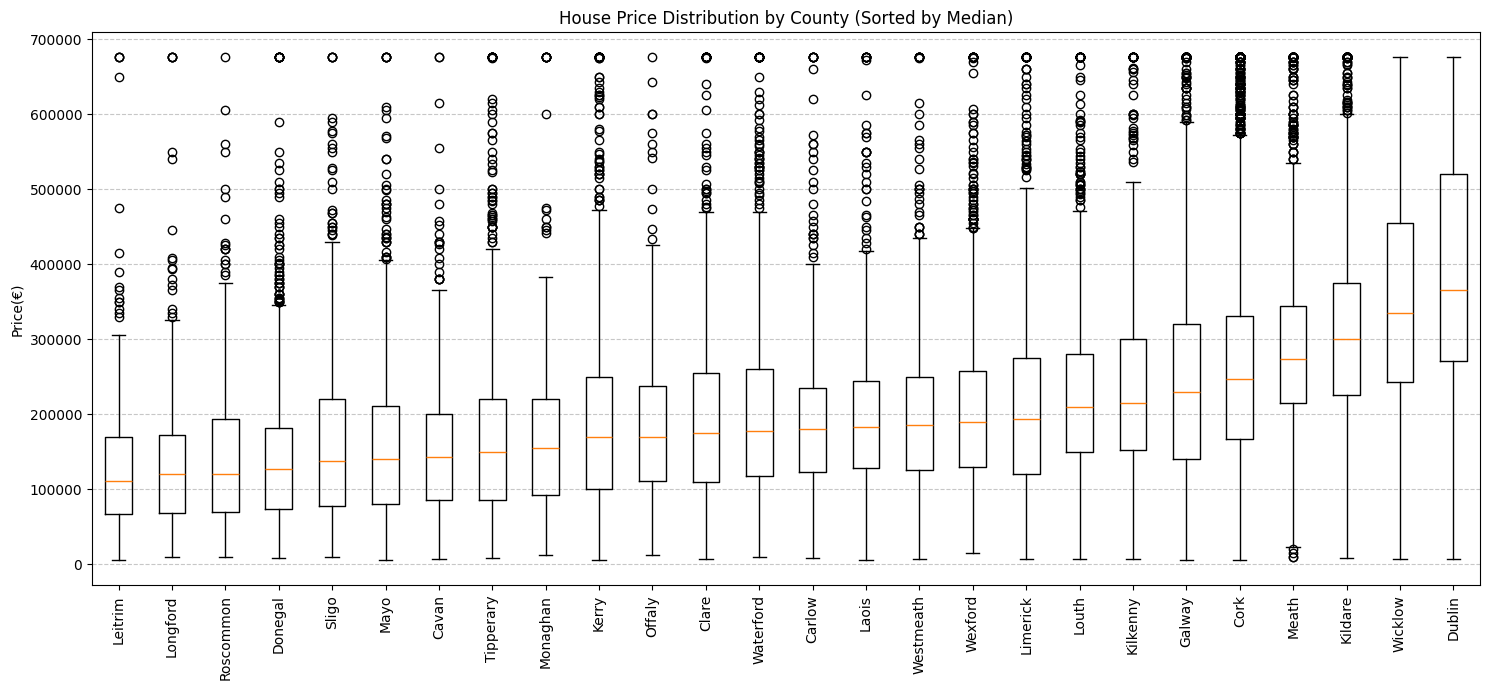

In [7]:

# sort by median
grouped = df.groupby('County')['Price(€)'].median().sort_values()

data_to_plot = [df[df['County'] == x]['Price(€)'] for x in grouped.index]


plt.figure(figsize=(15, 7))
plt.boxplot(data_to_plot, labels=grouped.index)

plt.xticks(rotation=90)
plt.ylabel('Price(€)')
plt.title('House Price Distribution by County (Sorted by Median)')
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

## 2. Pair the price with Region
In region, we focus on the districts inside Dublin. And the result is similar to the result of price-county pair. If we take the median values as plots, than the relationship is close to linear.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15444\2002892232.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('Region')['Price(€)'].median().sort_values()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15444\2002892232.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=grouped.index)


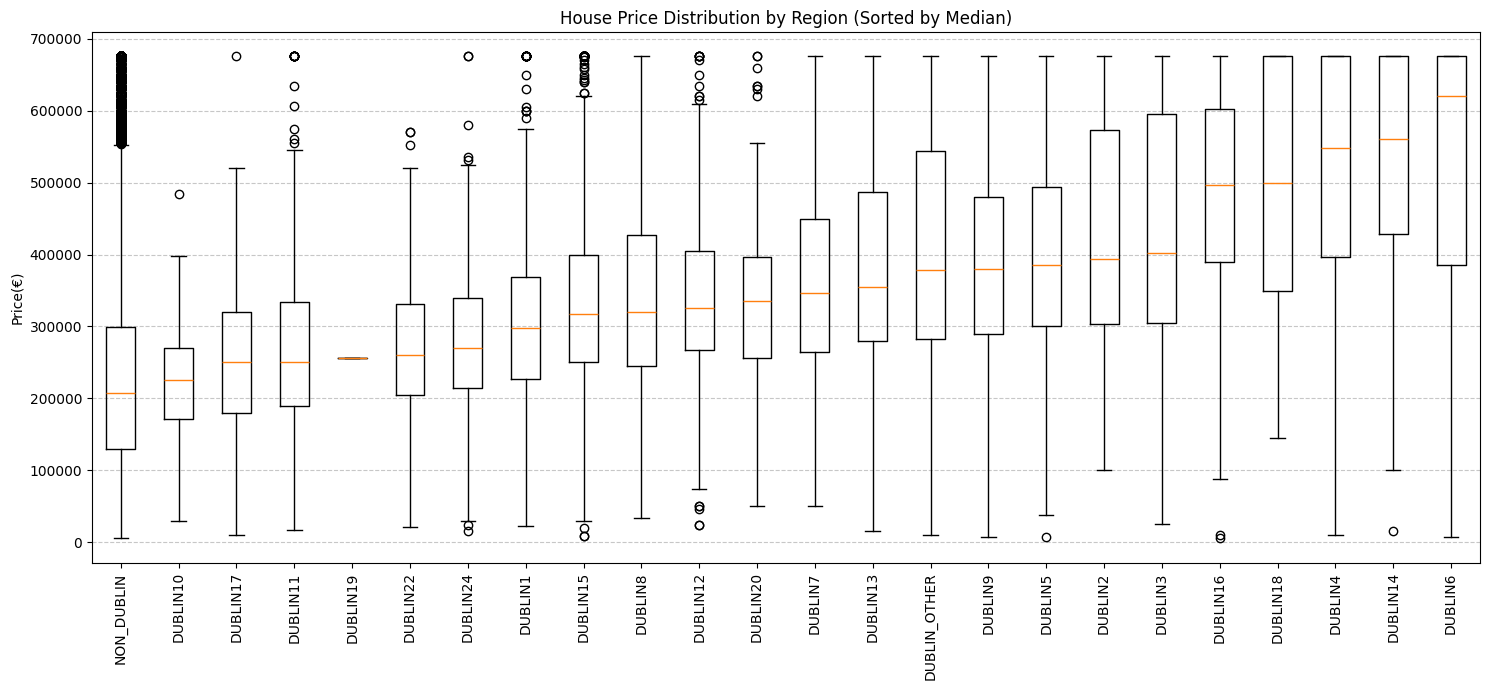

In [8]:

# sort by median
grouped = df.groupby('Region')['Price(€)'].median().sort_values()

data_to_plot = [df[df['Region'] == x]['Price(€)'] for x in grouped.index]


plt.figure(figsize=(15, 7))
plt.boxplot(data_to_plot, labels=grouped.index)

plt.xticks(rotation=90)
plt.ylabel('Price(€)')
plt.title('House Price Distribution by Region (Sorted by Median)')
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

### Feature engineering of county and region
As county and region are both features of geography, we are going to integrate them as one feature. That is, for those in county Dublin, we substitute the value with region. The feature should be numeric for modeling, so for the each region, we use the average price of that region as the value of the feature.




## 3. Pair the price with SaleYear
The result shows a linear relation ship between SaleYear and the median of price.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15444\1065106022.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('SaleYear')['Price(€)'].median()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15444\1065106022.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=grouped.index)


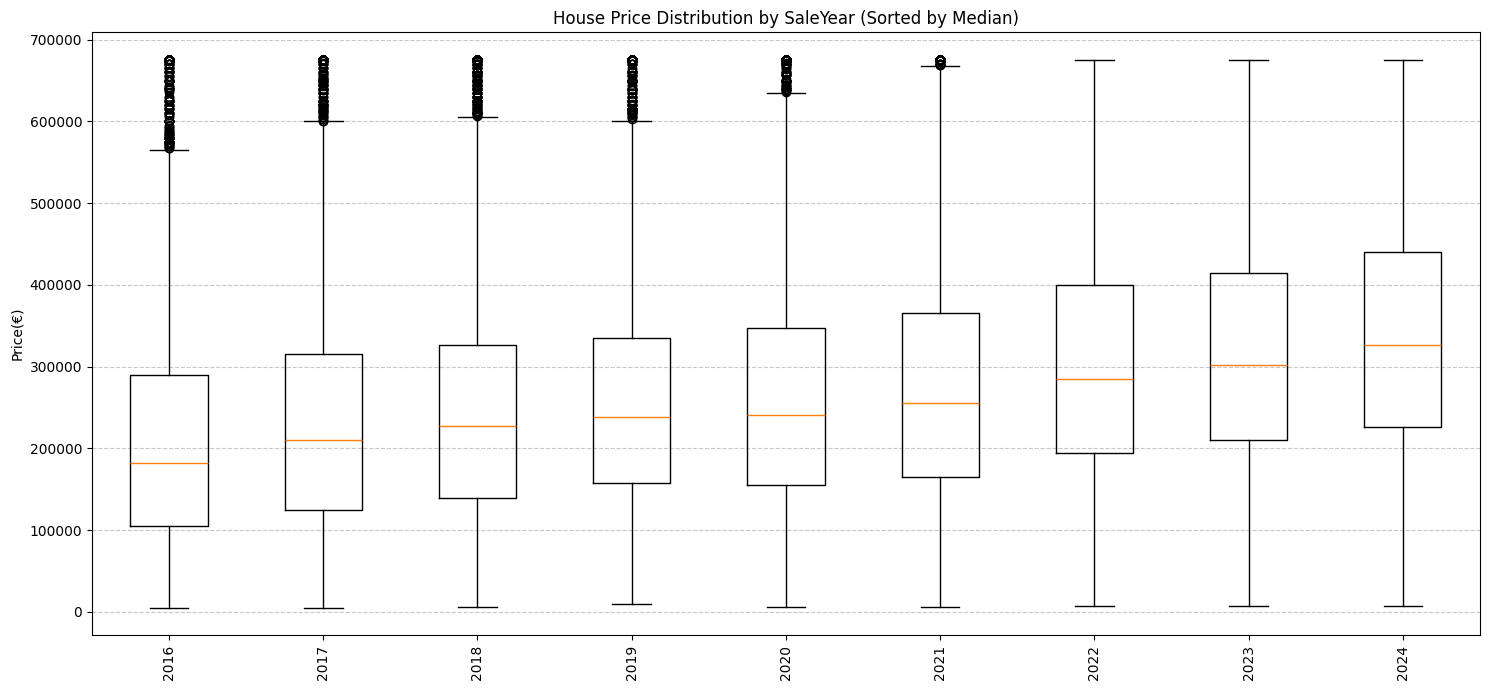

In [9]:
# sort by year
grouped = df.groupby('SaleYear')['Price(€)'].median()

data_to_plot = [df[df['SaleYear'] == x]['Price(€)'] for x in grouped.index]


plt.figure(figsize=(15, 7))
plt.boxplot(data_to_plot, labels=grouped.index)

plt.xticks(rotation=90)
plt.ylabel('Price(€)')
plt.title('House Price Distribution by SaleYear (Sorted by Median)')
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

## 4. Pair the price with SaleMonth
Result shows no direct relationship between month and price. 

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15444\1322693201.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('SaleMonth')['Price(€)'].median()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15444\1322693201.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=grouped.index)


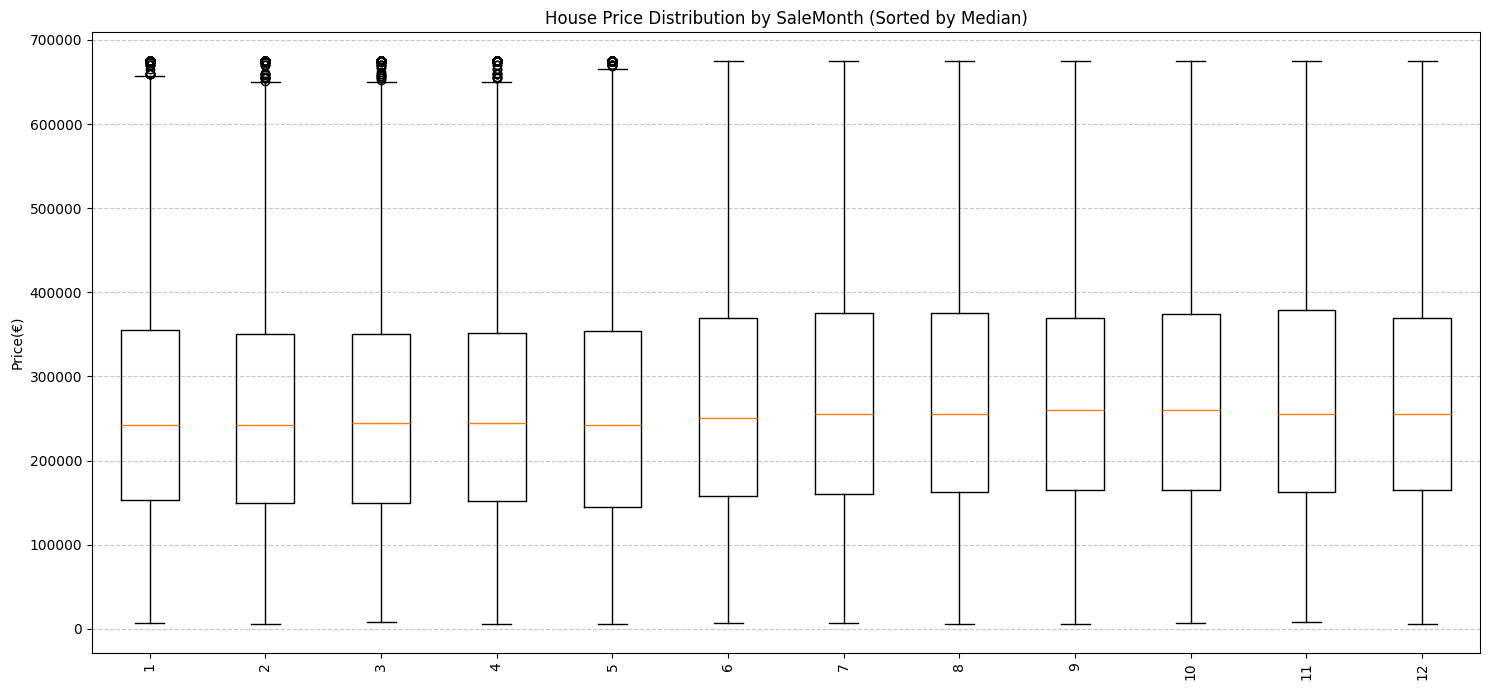

In [10]:

# sort by month
grouped = df.groupby('SaleMonth')['Price(€)'].median()

data_to_plot = [df[df['SaleMonth'] == x]['Price(€)'] for x in grouped.index]


plt.figure(figsize=(15, 7))
plt.boxplot(data_to_plot, labels=grouped.index)

plt.xticks(rotation=90)
plt.ylabel('Price(€)')
plt.title('House Price Distribution by SaleMonth (Sorted by Median)')
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

## 5. Pair price with YearMonth
But as month is part of the time feature, to better find the relationship between time and price, we need to combine year and month together to pair with price. The result shows that there is a linear relationship between price and time by month.

In [11]:
# combine year and month together.
df['YearMonth']=df['SaleYear'].astype('int64')*100+df['SaleMonth'].astype('int64')
df['YearMonth']=df['YearMonth'].astype('category')
df['SaleYear']=df['SaleYear'].astype('category')
df['SaleMonth']=df['SaleMonth'].astype('category')

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15444\276334388.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('YearMonth')['Price(€)'].median()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15444\276334388.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=grouped.index)


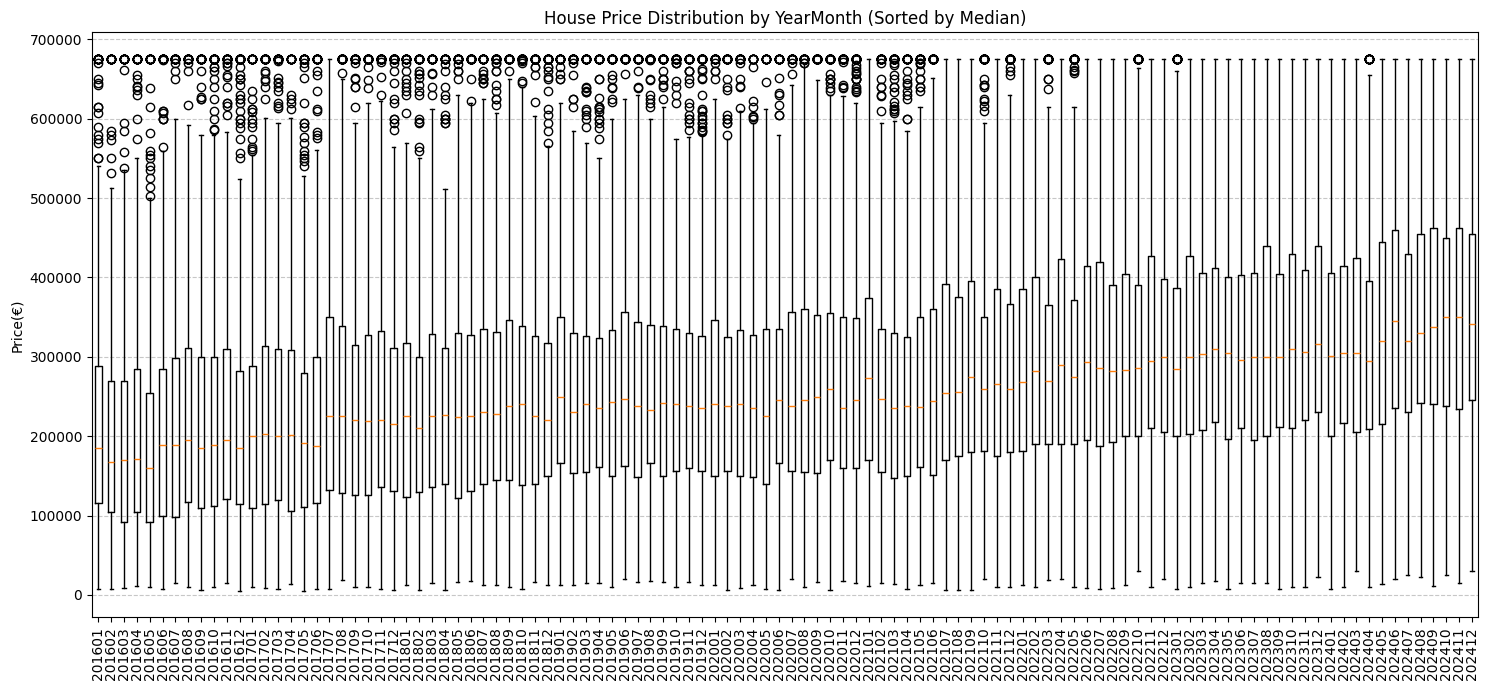

In [12]:
# pair the price with YearMonth

# sort by YearMonth
grouped = df.groupby('YearMonth')['Price(€)'].median()

data_to_plot = [df[df['YearMonth'] == x]['Price(€)'] for x in grouped.index]


plt.figure(figsize=(15, 7))
plt.boxplot(data_to_plot, labels=grouped.index)

plt.xticks(rotation=90)
plt.ylabel('Price(€)')
plt.title('House Price Distribution by YearMonth (Sorted by Median)')
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

## 6. Pair the price with NotFullMarketPrice
The result shows that there is apparent difference between the two categaries of the feature. We need to change it into binary number for modeling.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15444\55224881.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('NotFullMarketPrice')['Price(€)'].median().sort_values()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15444\55224881.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=grouped.index)


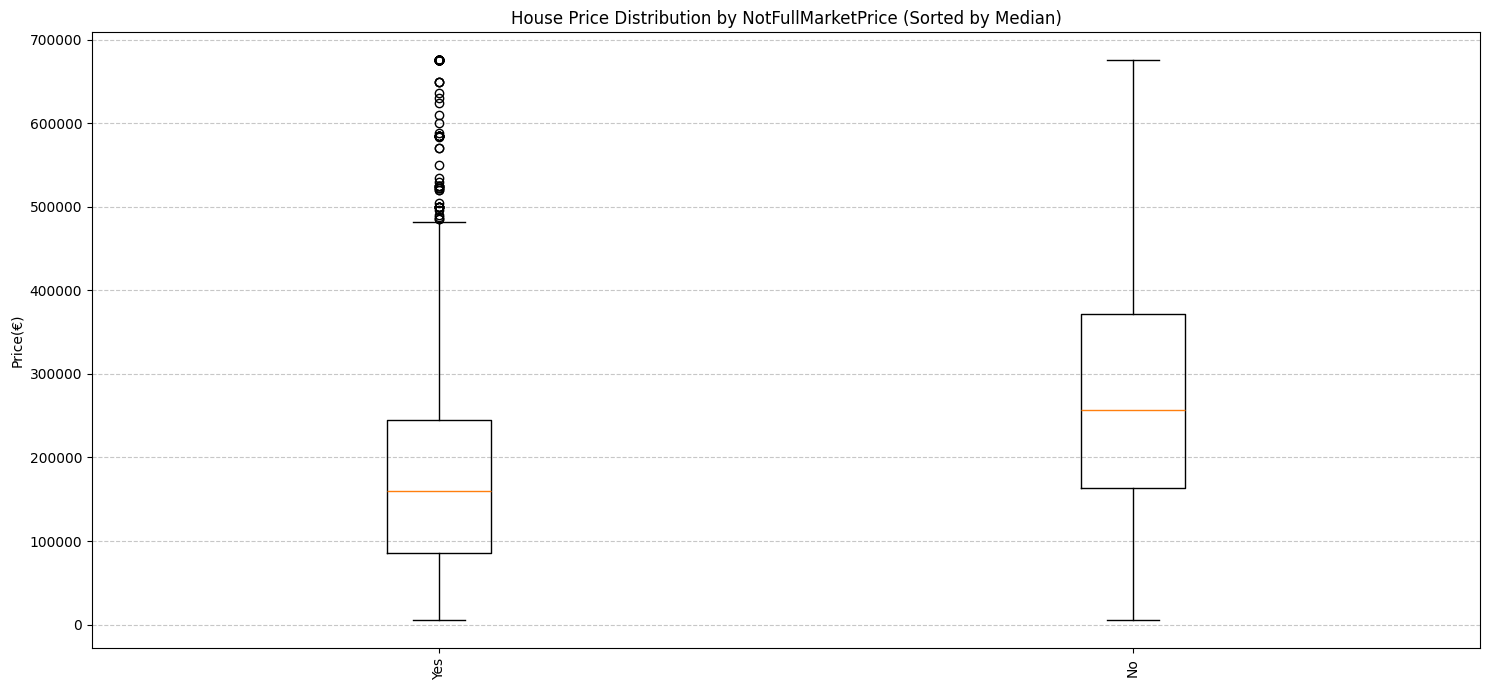

In [13]:
# sort by median
grouped = df.groupby('NotFullMarketPrice')['Price(€)'].median().sort_values()

data_to_plot = [df[df['NotFullMarketPrice'] == x]['Price(€)'] for x in grouped.index]


plt.figure(figsize=(15, 7))
plt.boxplot(data_to_plot, labels=grouped.index)

plt.xticks(rotation=90)
plt.ylabel('Price(€)')
plt.title('House Price Distribution by NotFullMarketPrice (Sorted by Median)')
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

## 7. Pair the price with VATExclusive
The result shows that there is apparent difference between the two categaries of the feature. We need to change it into binary number for modeling.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15444\1832901416.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('VATExclusive')['Price(€)'].median().sort_values()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15444\1832901416.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=grouped.index)


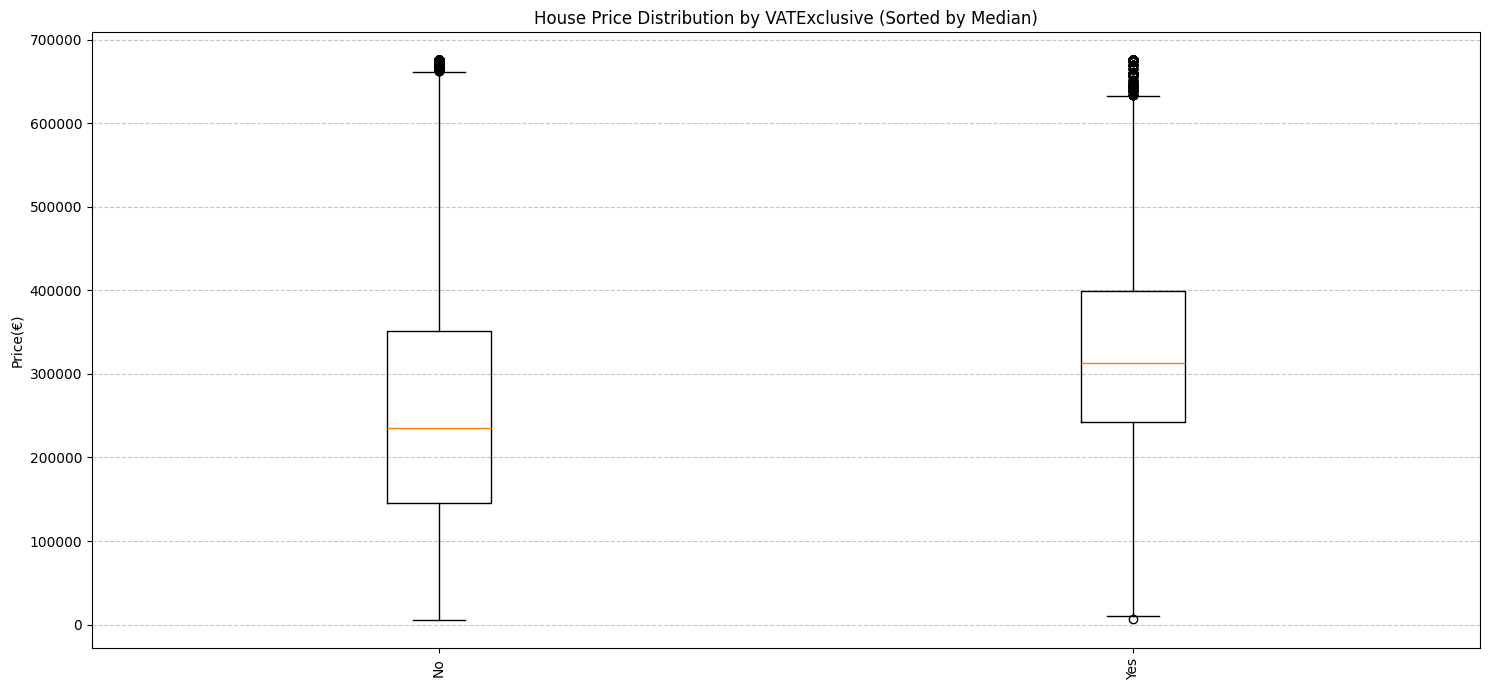

In [14]:
# sort by median
grouped = df.groupby('VATExclusive')['Price(€)'].median().sort_values()

data_to_plot = [df[df['VATExclusive'] == x]['Price(€)'] for x in grouped.index]


plt.figure(figsize=(15, 7))
plt.boxplot(data_to_plot, labels=grouped.index)

plt.xticks(rotation=90)
plt.ylabel('Price(€)')
plt.title('House Price Distribution by VATExclusive (Sorted by Median)')
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

## 8. Pair the price with DescriptionofProperty
The result shows that there is apparent difference between the three categaries of the feature. And we did some more investigation. There are 4 rows with value "Teach/Árasán Cónaithe Atháimhe", and this is actually "Second-Hand Dwelling house /Apartment" in Irish. So in feature engineering, we are also change DescriptionofProperty into binary numbers and assign "Second-Hand Dwelling house /Apartment" and "Teach/Árasán Cónaithe Atháimhe" with the same value.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15444\1038399458.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('DescriptionofProperty')['Price(€)'].median().sort_values()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15444\1038399458.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=grouped.index)


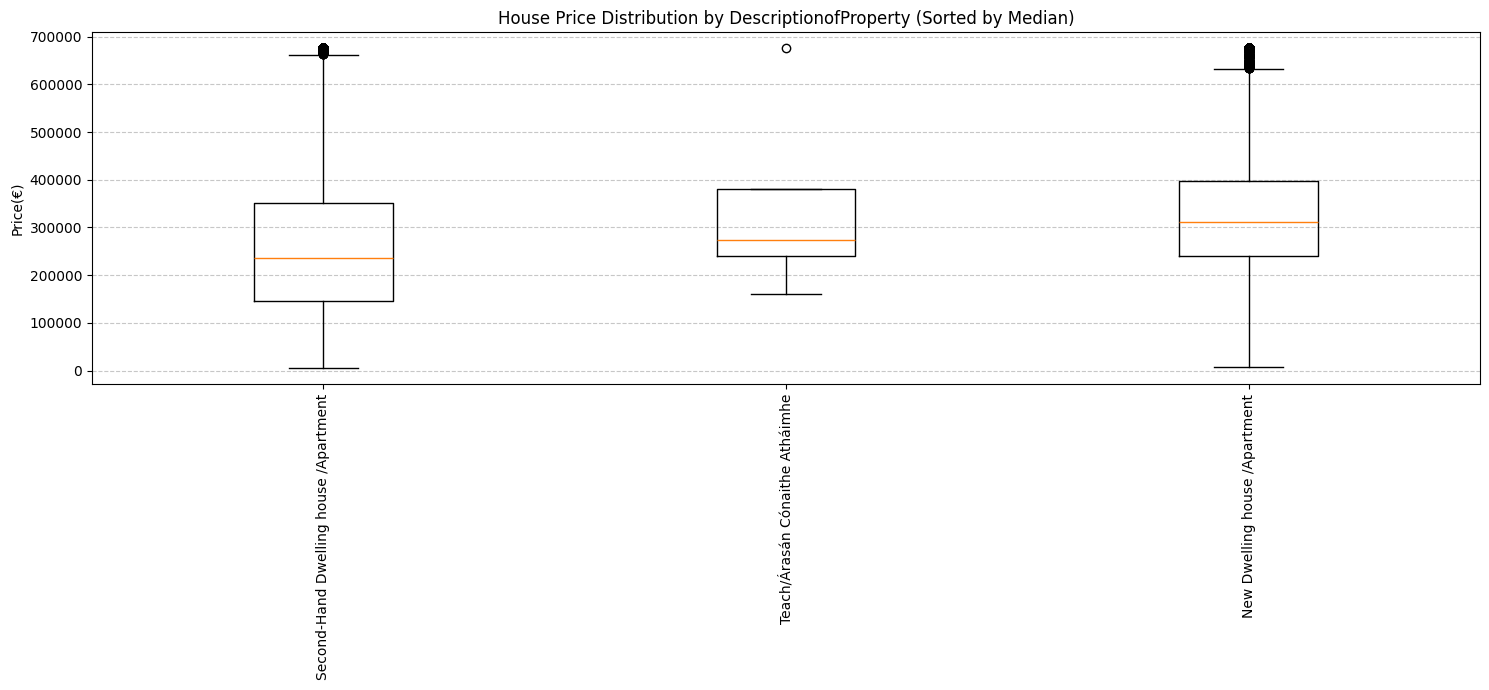

In [15]:
# sort by median
grouped = df.groupby('DescriptionofProperty')['Price(€)'].median().sort_values()

data_to_plot = [df[df['DescriptionofProperty'] == x]['Price(€)'] for x in grouped.index]


plt.figure(figsize=(15, 7))
plt.boxplot(data_to_plot, labels=grouped.index)

plt.xticks(rotation=90)
plt.ylabel('Price(€)')
plt.title('House Price Distribution by DescriptionofProperty (Sorted by Median)')
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

In [16]:
df['DescriptionofProperty'].value_counts()

DescriptionofProperty
Second-Hand Dwelling house /Apartment    44139
New Dwelling house /Apartment             9853
Teach/Árasán Cónaithe Atháimhe               4
Name: count, dtype: int64

Conclusion:
Two features appears linear relationship with price according to the plots: Geogaraphy feature (region and county) and time feature (YearMonth).
Three binary features appears relative to price: NotFullMarketPrice, VATExclusive, DescriptionofProperty

# Feature Engineering
## 1. SaleYear and SaleMonth
Convert them into a month index

In [17]:
# change data type of saleyear and salemonth
df["SaleYear"] = df["SaleYear"].astype(int)
df["SaleMonth"] = df["SaleMonth"].astype(int)
# create month index starting from 2016-01
df["SaleMonthIndex"] = (df["SaleYear"] - 2016) * 12 + df["SaleMonth"]
# check result
df[["SaleYear", "SaleMonth", "SaleMonthIndex"]].head(12000)

,SaleYear,SaleMonth,SaleMonthIndex
0,2016,7,7
1,2016,12,12
2,2016,8,8
3,2016,2,2
4,2016,10,10
...,...,...,...
11995,2017,4,16
11996,2017,9,21
11997,2017,1,13
11998,2018,10,34


## 2. NotFullMarketPrice
change it into binary number, yes-1, no-0

In [18]:
print(df["NotFullMarketPrice"].unique())
df["NotFullMarketPrice"] = df["NotFullMarketPrice"].map({
    "Yes": 1,
    "No": 0
})
print(df["NotFullMarketPrice"].head())

['No', 'Yes']
Categories (2, object): ['No', 'Yes']
0    0
1    1
2    0
3    0
4    0
Name: NotFullMarketPrice, dtype: category
Categories (2, int64): [0, 1]


## 3. VATExclusive
change it into binary number, yes-1, no-0

In [19]:
print(df["VATExclusive"].unique())
df["VATExclusive"] = df["VATExclusive"].map({
    "Yes": 1,
    "No": 0
})
print(df["VATExclusive"].head())

['No', 'Yes']
Categories (2, object): ['No', 'Yes']
0    0
1    0
2    0
3    1
4    0
Name: VATExclusive, dtype: category
Categories (2, int64): [0, 1]


## 4. DescriptionofProperty
change it into two binary feature, new -1，second-hand -0.    

'Teach/Árasán Cónaithe Atháimhe' means second house/apartment in Irish, so we all merge 'Teach/Árasán Cónaithe Atháimhe' into second-hand house.

In [20]:
print(df["DescriptionofProperty"].unique())

['Second-Hand Dwelling house /Apartment', 'New Dwelling house /Apartment', 'Teach/Árasán Cónaithe Atháimhe']
Categories (3, object): ['New Dwelling house /Apartment', 'Second-Hand Dwelling house /Apartment', 'Teach/Árasán Cónaithe Atháimhe']


In [21]:
df["DescriptionofProperty"] = df["DescriptionofProperty"].map({
    "Second-Hand Dwelling house /Apartment": 0,
    "New Dwelling house /Apartment": 1,
    "Teach/Árasán Cónaithe Atháimhe":0
})
print(df["DescriptionofProperty"].head(1000))

0      0
1      0
2      0
3      1
4      0
      ..
995    0
996    0
997    0
998    1
999    0
Name: DescriptionofProperty, Length: 1000, dtype: int64


## 5. County and Region encoding
Strategy:<br>
(1) To ensure statistical reliability and prevent Data Leakage, geographic features are encoded using a Time-Lagged Target Encoding approach. The encoding follows a hierarchical "back-off" logic to handle data sparsity:<br>
(a) Temporal Consistency: Observations in Year N are encoded using the mean property price from the preceding period (Year N-1). This simulates real-world logic and ensures no future information influences the model.<br>
(b) Minimum Sample Threshold: A minimum of 10 observations is required to calculate a valid regional mean. If this threshold is met, the single-year mean is applied.<br>
(c) Adaptive Back-off Mechanism:<br>
Window Expansion: If the sample size for N-1 is below 10, the calculation window expands to include the last two years (N-1 and N-2).<br>
Imputation: For Dublin sub-districts that fail the 2-year aggregate threshold, the encoding falls back to the DUBLIN_OTHER surrogate value. According to the samples, there are enough samples for other counties to calculate the average price.

In [22]:
# firstly, integrate county and region together as region.
df['Region'] = np.where(df['Region'] == 'NON_DUBLIN', df['County'], df['Region'])

df['Region'].value_counts()

Region
DUBLIN_OTHER    8051
Cork            6038
Kildare         3109
Galway          2457
Meath           2347
Limerick        1947
Wexford         1896
Wicklow         1866
Louth           1497
Waterford       1481
Kerry           1473
Tipperary       1403
Donegal         1382
Mayo            1284
Clare           1223
Westmeath       1037
DUBLIN15         973
Laois            893
Kilkenny         874
Roscommon        861
Sligo            819
Cavan            802
Offaly           702
DUBLIN8          602
Carlow           592
DUBLIN7          558
DUBLIN12         524
DUBLIN4          514
DUBLIN24         513
DUBLIN9          509
DUBLIN18         486
Leitrim          458
Longford         440
Monaghan         437
DUBLIN11         435
DUBLIN3          432
DUBLIN16         415
DUBLIN14         410
DUBLIN6          402
DUBLIN5          367
DUBLIN13         336
DUBLIN1          326
DUBLIN22         296
DUBLIN2          208
DUBLIN10         145
DUBLIN20          94
DUBLIN17          81
DUBLIN

In [23]:
# There is only one 'DUBLIN19', and it could be noise. So merge it into 'DUBLIN_OTHER'

df['Region']=df['Region'].replace('DUBLIN19','DUBLIN_OTHER')
df['Region'].value_counts()

Region
DUBLIN_OTHER    8052
Cork            6038
Kildare         3109
Galway          2457
Meath           2347
Limerick        1947
Wexford         1896
Wicklow         1866
Louth           1497
Waterford       1481
Kerry           1473
Tipperary       1403
Donegal         1382
Mayo            1284
Clare           1223
Westmeath       1037
DUBLIN15         973
Laois            893
Kilkenny         874
Roscommon        861
Sligo            819
Cavan            802
Offaly           702
DUBLIN8          602
Carlow           592
DUBLIN7          558
DUBLIN12         524
DUBLIN4          514
DUBLIN24         513
DUBLIN9          509
DUBLIN18         486
Leitrim          458
Longford         440
Monaghan         437
DUBLIN11         435
DUBLIN3          432
DUBLIN16         415
DUBLIN14         410
DUBLIN6          402
DUBLIN5          367
DUBLIN13         336
DUBLIN1          326
DUBLIN22         296
DUBLIN2          208
DUBLIN10         145
DUBLIN20          94
DUBLIN17          81
Name: 

In [24]:
# check the samples grouped by region and year both in a single year and in two years that are less than 10.

# pair the region with year
annual_counts = df.groupby(['SaleYear', 'Region']).size().reset_index(name='single_year_count')

# count the number of samples of the same region in two yeas.
annual_counts['two_year_total'] = annual_counts.groupby('Region')['single_year_count'].rolling(window=2, min_periods=1).sum().reset_index(level=0, drop=True)

# pick those less than 10 and null values out.
sparse_1y = annual_counts[(annual_counts['single_year_count'] < 10) | (annual_counts['single_year_count'].isna())]
sparse_2y = annual_counts[(annual_counts['two_year_total'] < 10) | (annual_counts['two_year_total'].isna())]

# print region-year pair less than 10 in a single year.
print(f"There are {len(sparse_1y)} year-region pairs whose samples are less than 10.")
print(sparse_1y.sort_values(by='single_year_count').to_string(index=False))

# print region-year pair less than 10 in two years.
if sparse_2y.empty:
    print("All samples in two_year_rolling are more than 10.")
else:
    print(f"There are {len(sparse_2y)} groups whose samples are less than 10 in two_year_rolling")
    print(sparse_2y[['SaleYear', 'Region', 'two_year_total']].sort_values(by='two_year_total').to_string(index=False))

There are 8 year-region pairs whose samples are less than 10.
 SaleYear   Region  single_year_count  two_year_total
     2018 DUBLIN20                  4            15.0
     2020 DUBLIN17                  4             9.0
     2024 DUBLIN17                  4            15.0
     2019 DUBLIN17                  5            15.0
     2019 DUBLIN20                  8            12.0
     2016 DUBLIN17                  8             8.0
     2023 DUBLIN20                  8            18.0
     2021 DUBLIN10                  9            24.0
There are 2 groups whose samples are less than 10 in two_year_rolling
 SaleYear   Region  two_year_total
     2016 DUBLIN17             8.0
     2020 DUBLIN17             9.0


Here, there are two groups whose samples do not meet the standard of >=10 in two years. They are both DUBLIN17. We are going to use the value of  DUBLIN_OTHER as subsititution, which includes all that does not specificate the distrcits.<br><br>

Now start to encoding the region.<br>
First, calculate the average price and count the number of samples grouped by region and year (both in single year and in two years).

In [25]:

# 1. calculate the mean and count sample number in a single year
stats_1y = df.groupby(['SaleYear', 'Region'])['Price(€)'].agg(['mean', 'count']).reset_index()

# 2. calculate the mean and count sample number in two years. As 2016 has no prevous year, its two-year values are filled with the value in 2016 only
stats_2y = stats_1y.sort_values(['Region', 'SaleYear']).copy()
stats_2y['rolling_sum'] = stats_2y.groupby('Region')['mean'].transform(lambda x: x * stats_2y['count'])
stats_2y['cum_count_2y'] = stats_2y.groupby('Region')['count'].transform(lambda x: x.rolling(window=2, min_periods=1).sum())
stats_2y['cum_mean_2y'] = stats_2y.groupby('Region')['rolling_sum'].transform(lambda x: x.rolling(window=2, min_periods=1).sum()) / stats_2y['cum_count_2y']

# 3. pick out the mean of DUBLIN_OTHER for later substitution 
stats_dublin_other = df[df['Region'] == 'DUBLIN_OTHER'].groupby('SaleYear')['Price(€)'].mean().reset_index(name='dublin_other_mean')

# 4. calculate the mean of 2016 only to fill the first year when merging.
stats_2016 = df[df['SaleYear'] == 2016].groupby('Region')['Price(€)'].mean().reset_index(name='mean_2016')

Second, move the results forward by one year (mean of year N now becomes mean of year N+1)

In [26]:

lookup_1y = stats_1y[['SaleYear', 'Region', 'mean', 'count']].copy()
lookup_1y['SaleYear'] += 1

lookup_2y = stats_2y[['SaleYear', 'Region', 'cum_mean_2y', 'cum_count_2y']].copy()
lookup_2y['SaleYear'] += 1

lookup_dublin = stats_dublin_other.copy()
lookup_dublin['SaleYear'] += 1


Third, merge the result into df and fill the encoding.

In [27]:
# 1. merge all the results into the main df
df = df.merge(lookup_1y, on=['SaleYear', 'Region'], how='left', suffixes=('', '_1y'))
df = df.merge(lookup_2y, on=['SaleYear', 'Region'], how='left')
df = df.merge(lookup_dublin, on='SaleYear', how='left')
df = df.merge(stats_2016, on='Region', how='left')

# 2. set the column of new feature
df['Region_Encoded'] = np.nan
threshold = 10  

# fill the new feature by Hierarchy

# Hierarchy 1: mean of prevous year that has more than 10 samples
mask1 = df['count'] >= threshold
df.loc[mask1, 'Region_Encoded'] = df['mean']

# Hierarchy 2: mean of prevous two years that has more than 10 samples
mask2 = df['Region_Encoded'].isna() & (df['cum_count_2y'] >= threshold)
df.loc[mask2, 'Region_Encoded'] = df['cum_mean_2y']

# Hierarchy 3: for Regions in Dublin which does not meet Hierarchy 2, fill with the mean of DUBLIN_OTHER
dublin_regions = [r for r in df['Region'].unique() if 'Dublin' in r or r.isdigit()]
is_dublin = df['Region'].isin(dublin_regions)
mask3 = df['Region_Encoded'].isna() & is_dublin
df.loc[mask3, 'Region_Encoded'] = df['dublin_other_mean']

# for the first year 2016, fill it with its own mean
mask_2016 = df['Region_Encoded'].isna() & (df['SaleYear'] == 2016)
df.loc[mask_2016, 'Region_Encoded'] = df['mean_2016']

# use the total mean to cover the bottom
df['Region_Encoded'] = df['Region_Encoded'].fillna(df['Price(€)'].mean())

# 3. drop the unnecissary columns
cols_to_drop = ['mean', 'count', 'cum_mean_2y', 'cum_count_2y', 'dublin_other_mean','mean_2016']
df.drop(columns=cols_to_drop, inplace=True)

Fourth, draw histogram and scatter plot to check the encoding.

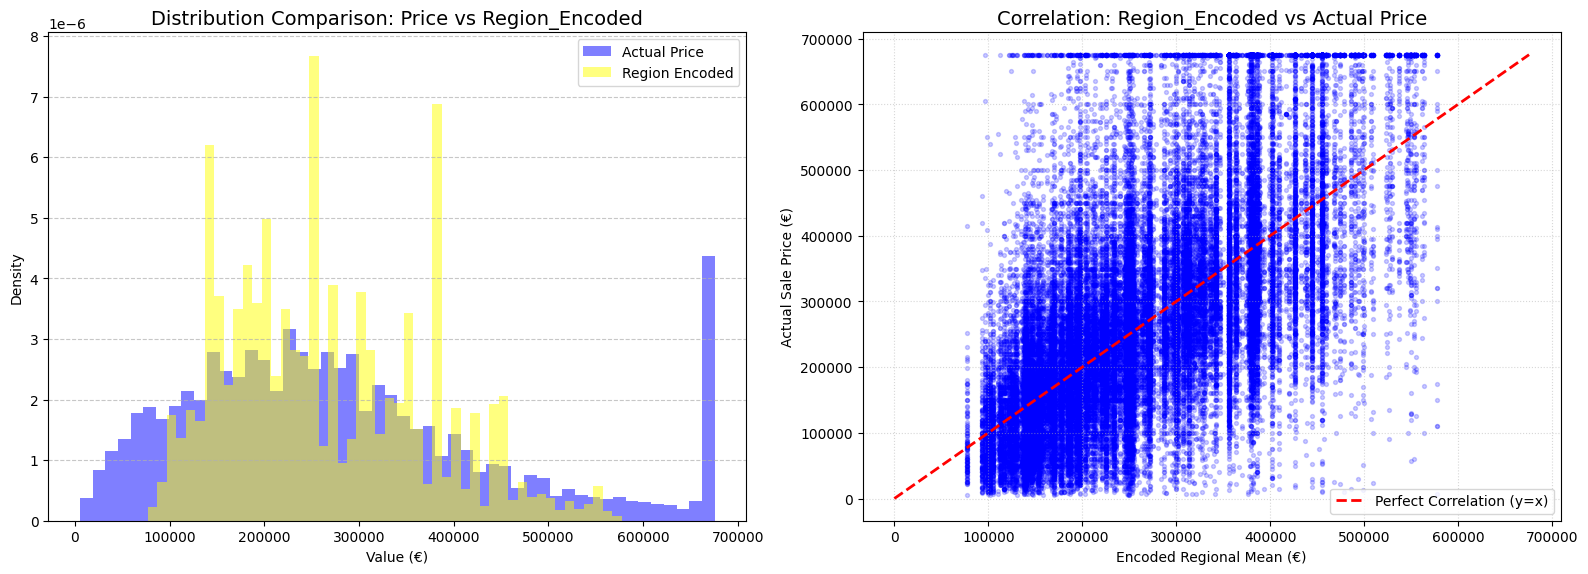

In [28]:

plt.figure(figsize=(16, 6))

# Histogram of Price and Region_Encoded
plt.subplot(1, 2, 1)
plt.hist(df['Price(€)'], bins=50, alpha=0.5, color='blue', label='Actual Price', density=True)
plt.hist(df['Region_Encoded'], bins=50, alpha=0.5, color='yellow', label='Region Encoded', density=True)

plt.title('Distribution Comparison: Price vs Region_Encoded', fontsize=14)
plt.xlabel('Value (€)')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Scatter Plot of Price and Region_Encoded
plt.subplot(1, 2, 2)
plt.scatter(df['Region_Encoded'], df['Price(€)'], alpha=0.2, s=8, color='blue')

# add a perfect line where y=x
limit = max(df['Price(€)'].max(), df['Region_Encoded'].max())
plt.plot([0, limit], [0, limit], color='red', linestyle='--', linewidth=2, label='Perfect Correlation (y=x)')

plt.title('Correlation: Region_Encoded vs Actual Price', fontsize=14)
plt.xlabel('Encoded Regional Mean (€)')
plt.ylabel('Actual Sale Price (€)')
plt.legend()
plt.grid(linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

# 6. Validate the engineered data

In [29]:
print(df.dtypes)

County                   category
Price(€)                  float64
NotFullMarketPrice       category
VATExclusive             category
DescriptionofProperty       int64
SaleYear                    int64
SaleMonth                   int64
Region                     object
YearMonth                category
SaleMonthIndex              int64
Region_Encoded            float64
dtype: object


Features for modeling are saved as numeric.<br>
Features not for modeling are saved as category.<br>


In [30]:

df['Region']=df['Region'].astype('category')
df['NotFullMarketPrice']=df['NotFullMarketPrice'].astype('int64')
df['VATExclusive']=df['VATExclusive'].astype('int64')
df['SaleMonth']=df['SaleMonth'].astype('category')

print(df.dtypes)

County                   category
Price(€)                  float64
NotFullMarketPrice          int64
VATExclusive                int64
DescriptionofProperty       int64
SaleYear                    int64
SaleMonth                category
Region                   category
YearMonth                category
SaleMonthIndex              int64
Region_Encoded            float64
dtype: object


In [31]:
df.isnull().sum()

County                   0
Price(€)                 0
NotFullMarketPrice       0
VATExclusive             0
DescriptionofProperty    0
SaleYear                 0
SaleMonth                0
Region                   0
YearMonth                0
SaleMonthIndex           0
Region_Encoded           0
dtype: int64

In [32]:
df.nunique()

County                     26
Price(€)                 5885
NotFullMarketPrice          2
VATExclusive                2
DescriptionofProperty       2
SaleYear                    9
SaleMonth                  12
Region                     47
YearMonth                 108
SaleMonthIndex            108
Region_Encoded            376
dtype: int64

In [33]:
df.head(10)

,County,Price(€),NotFullMarketPrice,VATExclusive,DescriptionofProperty,SaleYear,SaleMonth,Region,YearMonth,SaleMonthIndex,Region_Encoded
0,Wexford,62500.0,0,0,0,2016,7,Wexford,201607,7,139293.222332
1,Cork,150000.0,1,0,0,2016,12,Cork,201612,12,197650.165353
2,Wexford,94000.0,0,0,0,2016,8,Wexford,201608,8,139293.222332
3,Leitrim,149500.0,0,1,1,2016,2,Leitrim,201602,2,77163.284643
4,Mayo,170000.0,0,0,0,2016,10,Mayo,201610,10,101368.216069
5,Galway,50000.0,0,0,0,2016,12,Galway,201612,12,170070.680423
6,Kildare,160000.0,0,0,0,2016,12,Kildare,201612,12,246046.031879
7,Dublin,15000.0,0,0,0,2016,10,DUBLIN14,201610,10,486409.449362
8,Waterford,160000.0,0,0,0,2016,8,Waterford,201608,8,142191.455549
9,Kilkenny,320000.0,0,1,1,2016,12,Kilkenny,201612,12,177437.082174


In [34]:
# back up the engineered dataset
df.to_csv('ppr-group-25204989-train-Engineered.csv', index=False, encoding='utf-8')

drop all the category columns and save the data for model.<br>
'SaleYear' should be dropped but we need it to group the data into training set and validation set, so we keep it.

In [35]:
col_to_drop=df.select_dtypes('category')
df.drop(columns=col_to_drop, inplace=True)
print(df.dtypes)


Price(€)                 float64
NotFullMarketPrice         int64
VATExclusive               int64
DescriptionofProperty      int64
SaleYear                   int64
SaleMonthIndex             int64
Region_Encoded           float64
dtype: object


In [36]:
print("="*70)
print("SAVING DATASET FOR MODELING")
print("="*70)

# Define output filename with version indicator
output_filename = 'ppr-group-25204989-train-Formodeling.csv'

# Write the cleaned dataframe to a csv file with UTF-8 encoding
df.to_csv(output_filename, index=False, encoding='utf-8')

print(f"\n✓ Dataset for modeling saved successfully")
print(f"\nFile Information:")
print(f"  Filename: {output_filename}")
print(f"  Location: Current working directory")
print(f"  Format: CSV (UTF-8 encoding)")
print(f"  Rows: {df.shape[0]}")
print(f"  Columns: {df.shape[1]}")
print(f"\nDataset is now ready for:")
print(f"  - Modeling (building predictive models)")
print("="*70)



SAVING DATASET FOR MODELING

✓ Dataset for modeling saved successfully

File Information:
  Filename: ppr-group-25204989-train-Formodeling.csv
  Location: Current working directory
  Format: CSV (UTF-8 encoding)
  Rows: 53996
  Columns: 7

Dataset is now ready for:
  - Modeling (building predictive models)
